# Methodologically sound hyperparameter optimization for a PINN

This notebook uses the parameterized heat-equation PINN as a realistic case study in hyperparameter optimization. The emphasis is not on finding a spectacular architecture. It is on designing a comparison whose result can be interpreted.

## Learning objectives

After working through this notebook, you should be able to:

- distinguish fitting, validation, confirmation, and final audit evidence;
- state an optimization objective and computational budget before starting a search;
- implement a transparent random-search baseline before using an optimization framework;
- explain why one noisy best trial is not yet a reliable model choice;
- compare configurations across common, fresh training seeds;
- report accuracy, variability, model size, and runtime without pretending they are interchangeable.

The default experiment is intentionally small and normally takes roughly one to three minutes on a recent CPU. It needs PyTorch, NumPy, Matplotlib, and Optuna from the [course environment](../../environment.yml).

## 1. Goal and experimental contract

We vary three hyperparameters:

- network width;
- number of hidden layers;
- Adam learning rate.

The **declared selection metric** is the mean relative $L^2$ solution error over a fixed validation suite. The analytical solution is used only for evaluation, never for fitting. In a problem without an analytical solution, this role would need trustworthy observations or an independently verified numerical solution. Optimizing the training residual would be weaker: a small local residual does not guarantee a small solution error.

Every search trial receives the same number of optimizer updates and collocation points. This controls the sample and update budget, but it is **not** an equal wall-clock or floating-point-operation budget: wider and deeper networks cost more. We therefore report parameter count and runtime alongside error rather than quietly treating them as equivalent.

The workflow is fixed before any results are seen:

1. Search with one common training seed and a fixed validation suite.
2. Re-evaluate a short list with several fresh, common seeds.
3. Select by mean confirmation validation error.
4. Consult the audit suite exactly once, after the choice is frozen.

Using common seeds makes configuration comparisons less noisy. It does not eliminate stochasticity or prove that the winner is universally best.

## 2. Setup

All choices that affect the experiment are collected here. Reducing epochs or trials is legitimate for a demonstration, but changing them after seeing results creates a different experiment. CPU is the default because this small, derivative-heavy workload does not automatically benefit from a GPU.

In [1]:
import math
import statistics
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import optuna
import torch
from torch import nn

optuna.logging.set_verbosity(optuna.logging.WARNING)
print(f"PyTorch {torch.__version__}; Optuna {optuna.__version__}")

PyTorch 2.13.0; Optuna 4.9.0


In [2]:
@dataclass(frozen=True)
class ProblemConfig:
    x_min: float = 0.0
    x_max: float = 1.0
    t_min: float = 0.0
    t_max: float = 1.0
    coefficient_min: float = -1.0
    coefficient_max: float = 1.0
    kappa_min: float = 0.05
    kappa_max: float = 0.20

    def input_bounds(self):
        lower = torch.tensor([
            self.x_min, self.t_min, self.coefficient_min,
            self.coefficient_min, self.kappa_min,
        ])
        upper = torch.tensor([
            self.x_max, self.t_max, self.coefficient_max,
            self.coefficient_max, self.kappa_max,
        ])
        return lower, upper


@dataclass(frozen=True)
class ExperimentConfig:
    width_options: tuple[int, ...] = (8, 16, 32, 64)
    hidden_layers_min: int = 1
    hidden_layers_max: int = 4
    learning_rate_min: float = 3.0e-4
    learning_rate_max: float = 4.0e-3
    trials_per_method: int = 8
    search_epochs: int = 400
    confirmation_epochs: int = 1_200
    collocation_batch_size: int = 256
    validation_case_count: int = 10
    audit_case_count: int = 10
    evaluation_n_x: int = 41
    evaluation_n_t: int = 21
    common_search_seed: int = 20_260_817
    random_search_seed: int = 31_415
    optuna_sampler_seed: int = 27_182
    validation_case_seed: int = 16_180
    audit_case_seed: int = 14_142
    confirmation_seeds: tuple[int, ...] = (10_007, 10_009, 10_037)
    use_cuda: bool = False


@dataclass(frozen=True)
class ModelConfig:
    width: int
    hidden_layers: int
    learning_rate: float


problem = ProblemConfig()
experiment = ExperimentConfig()
using_cuda = experiment.use_cuda and torch.cuda.is_available()
device = torch.device("cuda" if using_cuda else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 3. Define the problem and model family

We solve

$$
\frac{\partial u}{\partial t}=\kappa\frac{\partial^2 u}{\partial x^2},
\qquad
u(x,0)=a_1\sin(\pi x)+a_2\sin(2\pi x),
$$

with $u(0,t)=u(1,t)=0$. The network input is $(x,t,a_1,a_2,\kappa)$. A hard-constrained trial solution satisfies the initial and boundary conditions for every network configuration, so architecture comparisons are not confounded by different loss-term weights.

This duplicates a small amount of code from the [parameterized heat-equation PINN notebook](../pinns/parameterized_heat_equation.ipynb) so the experiment is self-contained and reproducible from top to bottom.

In [3]:
def initial_profile(x, a1, a2, *, x_min, x_max):
    scaled_x = (x - x_min) / (x_max - x_min)
    return (
        a1 * torch.sin(math.pi * scaled_x)
        + a2 * torch.sin(2.0 * math.pi * scaled_x)
    )


def exact_solution(inputs, problem):
    # Evaluation reference only: never called by the fitting loop.
    x, t, a1, a2, kappa = inputs.unbind(dim=1)
    length = problem.x_max - problem.x_min
    elapsed_time = t - problem.t_min
    first_rate = (math.pi / length) ** 2
    second_rate = (2.0 * math.pi / length) ** 2
    profile_1 = initial_profile(
        x, a1, torch.zeros_like(a2),
        x_min=problem.x_min, x_max=problem.x_max,
    )
    profile_2 = initial_profile(
        x, torch.zeros_like(a1), a2,
        x_min=problem.x_min, x_max=problem.x_max,
    )
    return (
        torch.exp(-kappa * first_rate * elapsed_time) * profile_1
        + torch.exp(-kappa * second_rate * elapsed_time) * profile_2
    )


class ParametricHeatPINN(nn.Module):
    def __init__(self, problem, *, width, hidden_layers):
        super().__init__()
        layers = [nn.Linear(5, width), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers.extend([nn.Linear(width, width), nn.Tanh()])
        layers.append(nn.Linear(width, 1))
        self.network = nn.Sequential(*layers)

        input_lower, input_upper = problem.input_bounds()
        self.register_buffer("input_lower", input_lower)
        self.register_buffer("input_upper", input_upper)

    def forward(self, inputs):
        x, t, a1, a2, _ = inputs.unbind(dim=1)
        scaled_inputs = 2.0 * (
            (inputs - self.input_lower)
            / (self.input_upper - self.input_lower)
        ) - 1.0
        starting_profile = initial_profile(
            x, a1, a2,
            x_min=self.input_lower[0],
            x_max=self.input_upper[0],
        )
        correction = self.network(scaled_inputs).squeeze(dim=1)
        constraint_factor = (
            (t - self.input_lower[1])
            * (x - self.input_lower[0])
            * (self.input_upper[0] - x)
        )
        return starting_profile + constraint_factor * correction

## 4. Separate fitting from evaluation

The fitting loop sees only newly sampled collocation points and the differential equation. It never sees validation or audit solution values. An explicit random-number generator makes the collocation stream independent of how many random numbers a particular architecture consumes during weight initialization.

In [4]:
def seed_model_initialization(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def random_parameters(n, problem, device, *, generator):
    coefficient_width = problem.coefficient_max - problem.coefficient_min
    a1 = problem.coefficient_min + coefficient_width * torch.rand(
        n, device=device, generator=generator
    )
    a2 = problem.coefficient_min + coefficient_width * torch.rand(
        n, device=device, generator=generator
    )
    kappa = problem.kappa_min + (
        problem.kappa_max - problem.kappa_min
    ) * torch.rand(n, device=device, generator=generator)
    return a1, a2, kappa


def sample_collocation_points(n, problem, device, *, generator):
    x = problem.x_min + (problem.x_max - problem.x_min) * torch.rand(
        n, device=device, generator=generator
    )
    t = problem.t_min + (problem.t_max - problem.t_min) * torch.rand(
        n, device=device, generator=generator
    )
    a1, a2, kappa = random_parameters(
        n, problem, device, generator=generator
    )
    return torch.column_stack([x, t, a1, a2, kappa]).requires_grad_(True)


def physics_residual(model, inputs):
    u = model(inputs)
    first_derivatives = torch.autograd.grad(
        u, inputs, grad_outputs=torch.ones_like(u), create_graph=True
    )[0]
    du_dx = first_derivatives[:, 0]
    du_dt = first_derivatives[:, 1]
    d2u_dx2 = torch.autograd.grad(
        du_dx, inputs, grad_outputs=torch.ones_like(du_dx), create_graph=True
    )[0][:, 0]
    return du_dt - inputs[:, 4] * d2u_dx2

In [5]:
def make_parameter_cases(seed, n_cases, problem, *, min_coefficient_norm=0.35):
    rng = np.random.default_rng(seed)
    cases = []
    while len(cases) < n_cases:
        a1 = rng.uniform(problem.coefficient_min, problem.coefficient_max)
        a2 = rng.uniform(problem.coefficient_min, problem.coefficient_max)
        if math.hypot(a1, a2) < min_coefficient_norm:
            continue
        kappa = rng.uniform(problem.kappa_min, problem.kappa_max)
        cases.append((float(a1), float(a2), float(kappa)))
    return tuple(cases)


def make_evaluation_inputs(case, problem, device, *, n_x, n_t):
    a1, a2, kappa = case
    x = torch.linspace(problem.x_min, problem.x_max, n_x, device=device)
    t = torch.linspace(problem.t_min, problem.t_max, n_t, device=device)
    tt, xx = torch.meshgrid(t, x, indexing="ij")
    return torch.column_stack([
        xx.ravel(), tt.ravel(),
        torch.full_like(xx.ravel(), a1),
        torch.full_like(xx.ravel(), a2),
        torch.full_like(xx.ravel(), kappa),
    ])


def score_cases(model, cases, problem, experiment, device):
    relative_errors = []
    model.eval()
    with torch.inference_mode():
        for case in cases:
            inputs = make_evaluation_inputs(
                case, problem, device,
                n_x=experiment.evaluation_n_x,
                n_t=experiment.evaluation_n_t,
            )
            prediction = model(inputs)
            reference = exact_solution(inputs, problem)
            relative_error = (
                torch.linalg.vector_norm(prediction - reference)
                / torch.linalg.vector_norm(reference)
            )
            relative_errors.append(relative_error.item())
    return {
        "mean": statistics.fmean(relative_errors),
        "standard_deviation": statistics.stdev(relative_errors),
        "maximum": max(relative_errors),
        "per_case": tuple(relative_errors),
    }

In [6]:
def run_configuration(
    model_config, *, training_seed, epochs, problem, experiment,
    validation_cases, device,
):
    seed_model_initialization(training_seed)
    model = ParametricHeatPINN(
        problem,
        width=model_config.width,
        hidden_layers=model_config.hidden_layers,
    ).to(device)
    collocation_generator = torch.Generator(device=device)
    collocation_generator.manual_seed(training_seed + 1)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=model_config.learning_rate
    )

    if device.type == "cuda":
        torch.cuda.synchronize()
    start_time = time.perf_counter()
    final_physics_loss = math.nan
    model.train()
    for _ in range(epochs):
        inputs = sample_collocation_points(
            experiment.collocation_batch_size, problem, device,
            generator=collocation_generator,
        )
        optimizer.zero_grad(set_to_none=True)
        residual = physics_residual(model, inputs)
        loss = residual.square().mean()
        loss.backward()
        optimizer.step()
        final_physics_loss = loss.item()

    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed_seconds = time.perf_counter() - start_time
    validation = score_cases(
        model, validation_cases, problem, experiment, device
    )
    parameter_count = sum(parameter.numel() for parameter in model.parameters())
    return {
        "model": model,
        "validation": validation,
        "parameter_count": parameter_count,
        "elapsed_seconds": elapsed_seconds,
        "final_physics_loss": final_physics_loss,
    }


def config_label(config):
    return (
        f"width={config.width}, layers={config.hidden_layers}, "
        f"lr={config.learning_rate:.2e}"
    )


def config_key(config):
    return (config.width, config.hidden_layers, config.learning_rate)

## 5. Fix the validation suite

The validation cases are fixed before searching. Cases with an almost-zero initial condition are excluded because relative error becomes unstable when the reference norm is nearly zero. This is a metric-domain decision, not a removal of inconvenient model failures.

These cases are independent evaluation points inside the parameter domain. Calling them wholly 'unseen' would be misleading: fitting continuously samples the same domain and may encounter nearby points, although it never receives their exact solution values.

Only the audit seed is declared at this stage. The audit cases themselves are not generated or evaluated until model selection is complete.

In [7]:
validation_cases = make_parameter_cases(
    experiment.validation_case_seed,
    experiment.validation_case_count,
    problem,
)
validation_array = np.asarray(validation_cases)
print("Fixed validation suite ranges:")
for name, values in zip(("a1", "a2", "kappa"), validation_array.T):
    print(f"  {name:5s}: {values.min(): .3f} to {values.max(): .3f}")

Fixed validation suite ranges:
  a1   : -0.811 to  0.836
  a2   : -0.935 to  0.703
  kappa:  0.051 to  0.179


## 6. Establish a transparent random-search baseline

Random search makes the mechanics visible: sample a configuration, fit it under the declared budget, evaluate it on validation cases, and retain the record. It is also a meaningful baseline for judging whether a more elaborate search strategy helped.

All candidates use the same fitting seed during this exploratory search. That is a deliberate variance-reduction device, not evidence that one seed is sufficient for the final comparison.

In [8]:
def sample_model_config(rng, experiment):
    log_learning_rate = rng.uniform(
        math.log(experiment.learning_rate_min),
        math.log(experiment.learning_rate_max),
    )
    return ModelConfig(
        width=int(rng.choice(experiment.width_options)),
        hidden_layers=int(rng.integers(
            experiment.hidden_layers_min,
            experiment.hidden_layers_max + 1,
        )),
        learning_rate=float(math.exp(log_learning_rate)),
    )


random_generator = np.random.default_rng(experiment.random_search_seed)
random_records = []
for trial_number in range(experiment.trials_per_method):
    model_config = sample_model_config(random_generator, experiment)
    result = run_configuration(
        model_config,
        training_seed=experiment.common_search_seed,
        epochs=experiment.search_epochs,
        problem=problem,
        experiment=experiment,
        validation_cases=validation_cases,
        device=device,
    )
    record = {
        "method": "random",
        "trial": trial_number,
        "config": model_config,
        "validation_mean": result["validation"]["mean"],
        "validation_standard_deviation": result["validation"]["standard_deviation"],
        "validation_maximum": result["validation"]["maximum"],
        "parameter_count": result["parameter_count"],
        "elapsed_seconds": result["elapsed_seconds"],
        "final_physics_loss": result["final_physics_loss"],
    }
    random_records.append(record)
    print(
        f"{trial_number:2d}  {config_label(model_config):42s}  "
        f"val={record['validation_mean']:.3e}  "
        f"time={record['elapsed_seconds']:.2f}s"
    )

 0  width=8, layers=1, lr=1.09e-03              val=1.121e+00  time=1.35s


 1  width=64, layers=4, lr=2.80e-03             val=9.910e-02  time=1.73s


 2  width=64, layers=4, lr=5.15e-04             val=1.908e-01  time=1.74s


 3  width=32, layers=1, lr=1.86e-03             val=5.049e-01  time=1.02s


 4  width=8, layers=1, lr=2.52e-03              val=7.258e-01  time=1.17s


 5  width=64, layers=2, lr=3.02e-04             val=8.843e-01  time=1.26s


 6  width=64, layers=1, lr=3.65e-04             val=1.129e+00  time=0.99s


 7  width=32, layers=1, lr=1.18e-03             val=8.864e-01  time=0.90s


### Check what the objective hides

The scalar objective is required by the search algorithm, but it is not the whole result. Compare mean and worst-case validation error, last-batch physics loss, parameter count, and runtime. A configuration can look attractive under one criterion and poor under another.

trial  mean error   worst case   last-batch loss  parameters   time
    1  9.910e-02   1.685e-01      3.586e-02         12929    1.73s
    2  1.908e-01   5.964e-01      4.440e-01         12929    1.74s
    3  5.049e-01   1.482e+00      1.228e+00           225    1.02s
    4  7.258e-01   2.014e+00      1.961e+00            57    1.17s
    5  8.843e-01   2.297e+00      2.960e+00          4609    1.26s
    7  8.864e-01   2.298e+00      2.971e+00           225    0.90s
    0  1.121e+00   2.790e+00      4.225e+00            57    1.35s
    6  1.129e+00   2.763e+00      4.468e+00           449    0.99s


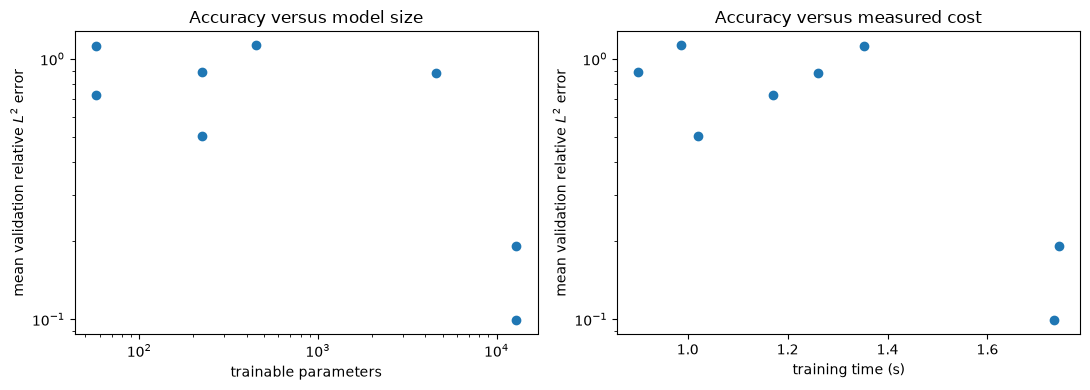

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(
    [record["parameter_count"] for record in random_records],
    [record["validation_mean"] for record in random_records],
)
axes[0].set(
    xscale="log", yscale="log", xlabel="trainable parameters",
    ylabel=r"mean validation relative $L^2$ error",
    title="Accuracy versus model size",
)
axes[1].scatter(
    [record["elapsed_seconds"] for record in random_records],
    [record["validation_mean"] for record in random_records],
)
axes[1].set(
    yscale="log", xlabel="training time (s)",
    ylabel=r"mean validation relative $L^2$ error",
    title="Accuracy versus measured cost",
)
fig.tight_layout()

print("trial  mean error   worst case   last-batch loss  parameters   time")
for record in sorted(random_records, key=lambda item: item["validation_mean"]):
    print(
        f"{record['trial']:5d}  {record['validation_mean']:.3e}   "
        f"{record['validation_maximum']:.3e}      "
        f"{record['final_physics_loss']:.3e}       "
        f"{record['parameter_count']:7d}   "
        f"{record['elapsed_seconds']:5.2f}s"
    )

## 7. Replace candidate generation with Optuna

Only candidate generation changes. The model, fitting budget, training seed, validation suite, and objective remain identical. This isolation is important: changing the search method and the experiment at the same time would make the comparison uninterpretable.

The TPE sampler begins with four startup trials before using its observations to guide later proposals. Eight trials are enough to illustrate the workflow, not enough to establish that TPE is generally superior to random search.

Pruning is deliberately disabled. Every candidate receives the declared budget, so an architecture that learns slowly is not silently compared with another architecture that trained longer. Pruning can save computation, but it introduces an additional policy that must itself be justified and validated.

In [10]:
def optuna_objective(
    trial, *, problem, experiment, validation_cases, device
):
    model_config = ModelConfig(
        width=trial.suggest_categorical(
            "width", list(experiment.width_options)
        ),
        hidden_layers=trial.suggest_int(
            "hidden_layers",
            experiment.hidden_layers_min,
            experiment.hidden_layers_max,
        ),
        learning_rate=trial.suggest_float(
            "learning_rate",
            experiment.learning_rate_min,
            experiment.learning_rate_max,
            log=True,
        ),
    )
    result = run_configuration(
        model_config,
        training_seed=experiment.common_search_seed,
        epochs=experiment.search_epochs,
        problem=problem,
        experiment=experiment,
        validation_cases=validation_cases,
        device=device,
    )
    trial.set_user_attr("validation_standard_deviation", result["validation"]["standard_deviation"])
    trial.set_user_attr("validation_maximum", result["validation"]["maximum"])
    trial.set_user_attr("parameter_count", result["parameter_count"])
    trial.set_user_attr("elapsed_seconds", result["elapsed_seconds"])
    trial.set_user_attr("final_physics_loss", result["final_physics_loss"])
    return result["validation"]["mean"]

In [11]:
sampler = optuna.samplers.TPESampler(
    seed=experiment.optuna_sampler_seed, n_startup_trials=4
)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(
    lambda trial: optuna_objective(
        trial,
        problem=problem,
        experiment=experiment,
        validation_cases=validation_cases,
        device=device,
    ),
    n_trials=experiment.trials_per_method,
)

optuna_records = []
for trial in study.trials:
    model_config = ModelConfig(**trial.params)
    record = {
        "method": "TPE",
        "trial": trial.number,
        "config": model_config,
        "validation_mean": trial.value,
        **trial.user_attrs,
    }
    optuna_records.append(record)
    print(
        f"{trial.number:2d}  {config_label(model_config):42s}  "
        f"val={trial.value:.3e}  "
        f"time={record['elapsed_seconds']:.2f}s"
    )

 0  width=32, layers=3, lr=1.43e-03             val=1.534e-01  time=1.21s
 1  width=8, layers=4, lr=1.10e-03              val=4.756e-01  time=1.27s
 2  width=64, layers=3, lr=1.43e-03             val=1.100e-01  time=1.41s
 3  width=16, layers=4, lr=6.66e-04             val=4.021e-01  time=1.37s
 4  width=64, layers=1, lr=3.29e-03             val=2.453e-01  time=1.01s
 5  width=64, layers=1, lr=3.50e-04             val=1.133e+00  time=1.05s
 6  width=64, layers=2, lr=3.56e-03             val=9.329e-02  time=1.27s
 7  width=32, layers=2, lr=3.96e-03             val=1.225e-01  time=1.10s


## 8. Compare searches under the same trial budget

The best-so-far curve answers a narrow question: how quickly did each run find a low validation score under this particular search seed and budget? It does not establish an ordering of search algorithms. That would require repeated searches, not merely repeated model training.

random: width=64, layers=4, lr=2.80e-03; validation=9.910e-02
TPE   : width=64, layers=2, lr=3.56e-03; validation=9.329e-02


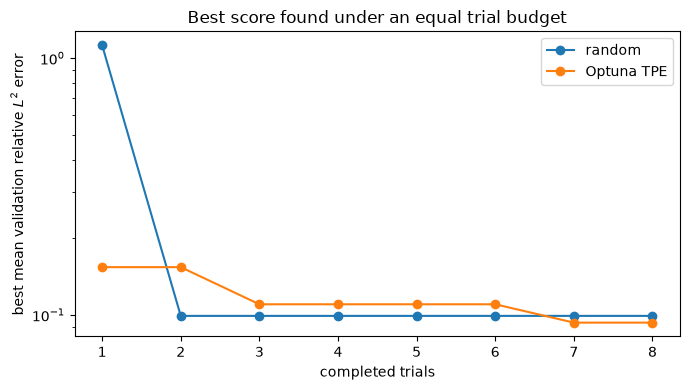

In [12]:
def best_so_far(records):
    values = np.asarray([record["validation_mean"] for record in records])
    return np.minimum.accumulate(values)


fig, ax = plt.subplots(figsize=(7, 4))
trial_numbers = np.arange(1, experiment.trials_per_method + 1)
ax.plot(trial_numbers, best_so_far(random_records), marker="o", label="random")
ax.plot(trial_numbers, best_so_far(optuna_records), marker="o", label="Optuna TPE")
ax.set(
    yscale="log", xlabel="completed trials",
    ylabel=r"best mean validation relative $L^2$ error",
    title="Best score found under an equal trial budget",
)
ax.legend()
fig.tight_layout()

for method, records in (("random", random_records), ("TPE", optuna_records)):
    best_record = min(records, key=lambda record: record["validation_mean"])
    print(
        f"{method:6s}: {config_label(best_record['config'])}; "
        f"validation={best_record['validation_mean']:.3e}"
    )

## 9. Confirm a shortlist across fresh seeds

Selecting the single best exploratory trial would reward luck. We take the three best distinct configurations across both searches and train each from scratch with the same three fresh seeds and a larger epoch budget. Sharing confirmation seeds creates paired comparisons: every configuration faces the same sources of training randomness.

The larger epoch budget is declared for every shortlisted configuration. Applying it only to the apparent winner would confound configuration with training effort.

In [13]:
all_search_records = sorted(
    random_records + optuna_records,
    key=lambda record: record["validation_mean"],
)
shortlist = []
seen_configurations = set()
for record in all_search_records:
    key = config_key(record["config"])
    if key in seen_configurations:
        continue
    seen_configurations.add(key)
    shortlist.append(record["config"])
    if len(shortlist) == 3:
        break

print("Shortlist chosen without audit evidence:")
for index, model_config in enumerate(shortlist, start=1):
    print(f"  C{index}: {config_label(model_config)}")

Shortlist chosen without audit evidence:
  C1: width=64, layers=2, lr=3.56e-03
  C2: width=64, layers=4, lr=2.80e-03
  C3: width=64, layers=3, lr=1.43e-03


In [14]:
confirmation_records = []
confirmation_runs = {}
for candidate_number, model_config in enumerate(shortlist, start=1):
    runs = []
    for training_seed in experiment.confirmation_seeds:
        result = run_configuration(
            model_config,
            training_seed=training_seed,
            epochs=experiment.confirmation_epochs,
            problem=problem,
            experiment=experiment,
            validation_cases=validation_cases,
            device=device,
        )
        run_record = {
            "candidate": candidate_number,
            "config": model_config,
            "training_seed": training_seed,
            "validation_mean": result["validation"]["mean"],
            "elapsed_seconds": result["elapsed_seconds"],
            "parameter_count": result["parameter_count"],
            "model": result["model"],
        }
        runs.append(run_record)
        confirmation_records.append(run_record)
    confirmation_runs[config_key(model_config)] = runs

confirmation_summary = []
for candidate_number, model_config in enumerate(shortlist, start=1):
    runs = confirmation_runs[config_key(model_config)]
    scores = [run["validation_mean"] for run in runs]
    summary = {
        "candidate": candidate_number,
        "config": model_config,
        "mean": statistics.fmean(scores),
        "standard_deviation": statistics.stdev(scores),
        "minimum": min(scores),
        "maximum": max(scores),
        "parameter_count": runs[0]["parameter_count"],
        "mean_time": statistics.fmean(
            run["elapsed_seconds"] for run in runs
        ),
    }
    confirmation_summary.append(summary)

print("candidate  mean validation ± seed SD       parameters   mean time")
for summary in confirmation_summary:
    print(
        f"C{summary['candidate']:<8d}"
        f"{summary['mean']:.3e} ± {summary['standard_deviation']:.2e}"
        f"      {summary['parameter_count']:7d}"
        f"      {summary['mean_time']:6.2f}s"
    )

candidate  mean validation ± seed SD       parameters   mean time
C1       6.144e-02 ± 1.87e-02         4609        3.88s
C2       5.619e-02 ± 3.31e-03        12929        5.15s
C3       6.376e-02 ± 8.62e-03         8769        4.51s


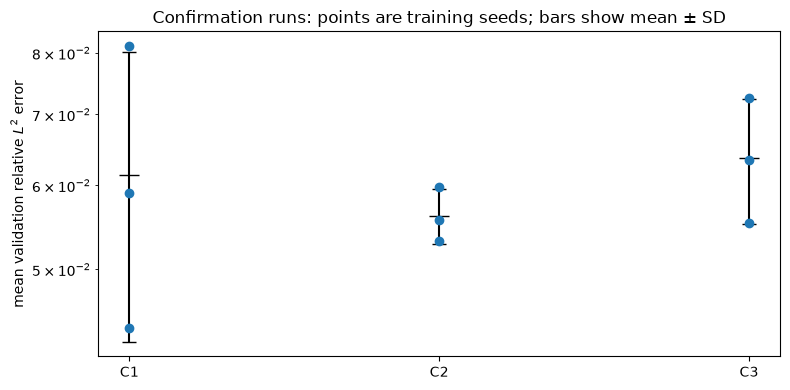

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
positions = np.arange(1, len(confirmation_summary) + 1)
for position, summary in zip(positions, confirmation_summary):
    scores = [
        run["validation_mean"]
        for run in confirmation_runs[config_key(summary["config"])]
    ]
    ax.scatter(np.full(len(scores), position), scores, color="tab:blue", zorder=3)
    ax.errorbar(
        position, summary["mean"], yerr=summary["standard_deviation"],
        color="black", capsize=5, marker="_", markersize=14,
    )
ax.set(
    xticks=positions,
    xticklabels=[f"C{index}" for index in positions],
    yscale="log",
    ylabel=r"mean validation relative $L^2$ error",
    title="Confirmation runs: points are training seeds; bars show mean ± SD",
)
fig.tight_layout()

## 10. Freeze the choice, then run the final audit

The declared selection rule is the lowest mean confirmation validation error. The standard deviation indicates sensitivity to training randomness; with only three seeds, it is descriptive rather than a precise uncertainty estimate. Small differences should not be promoted into strong architectural conclusions.

After the next cell evaluates the audit suite, **do not** use its result to revise the architecture, learning rate, seeds, epoch budget, or metric. Doing so would turn the audit suite into another validation suite. A revised experiment needs a fresh audit suite.

In [16]:
selected_summary = min(confirmation_summary, key=lambda summary: summary["mean"])
selected_config = selected_summary["config"]
print("Frozen selection:")
print(f"  C{selected_summary['candidate']}: {config_label(selected_config)}")
print(
    f"  confirmation validation = {selected_summary['mean']:.3e} "
    f"± {selected_summary['standard_deviation']:.2e} across seeds"
)

Frozen selection:
  C2: width=64, layers=4, lr=2.80e-03
  confirmation validation = 5.619e-02 ± 3.31e-03 across seeds


In [17]:
audit_cases = make_parameter_cases(
    experiment.audit_case_seed,
    experiment.audit_case_count,
    problem,
)
selected_runs = confirmation_runs[config_key(selected_config)]
audit_records = []
for run in selected_runs:
    audit_score = score_cases(
        run["model"], audit_cases, problem, experiment, device
    )
    audit_records.append({
        "training_seed": run["training_seed"],
        "validation_mean": run["validation_mean"],
        "audit_mean": audit_score["mean"],
        "audit_maximum": audit_score["maximum"],
    })

print("seed       validation mean    audit mean       audit maximum")
for record in audit_records:
    print(
        f"{record['training_seed']:8d}   "
        f"{record['validation_mean']:.3e}        "
        f"{record['audit_mean']:.3e}        "
        f"{record['audit_maximum']:.3e}"
    )

validation_scores = [record["validation_mean"] for record in audit_records]
audit_scores = [record["audit_mean"] for record in audit_records]
print(
    "Validation across seeds: "
    f"{statistics.fmean(validation_scores):.3e} ± "
    f"{statistics.stdev(validation_scores):.2e}"
)
print(
    "Final audit across seeds: "
    f"{statistics.fmean(audit_scores):.3e} ± "
    f"{statistics.stdev(audit_scores):.2e}"
)

seed       validation mean    audit mean       audit maximum
   10007   5.563e-02        6.081e-02        8.194e-02
   10009   5.975e-02        4.795e-02        1.135e-01
   10037   5.320e-02        4.953e-02        1.105e-01
Validation across seeds: 5.619e-02 ± 3.31e-03
Final audit across seeds: 5.276e-02 ± 7.02e-03


## 11. Checks and interpretation exercise

**Timebox: 10 minutes.** Use the executed evidence rather than the trial ranking alone.

1. Did the configuration with the best exploratory score remain best across fresh seeds? Explain why either outcome is plausible.
2. Are the confirmation differences large relative to their seed-to-seed variability? What claim is justified, and what stronger claim is not?
3. Did TPE find a better candidate than random search under this one equal trial budget? Why does that not establish that TPE is the better algorithm in general?
4. Which configuration would you choose if training time or parameter count were a hard constraint? State the constraint before choosing.
5. Why would replacing validation solution error with training residual change the scientific meaning of the objective?
6. If the audit result is disappointing, what may be reported now, and what must wait for a new experiment with a fresh audit suite?

### Optional transfer task

Redesign the budget as a fixed wall-clock limit rather than fixed optimizer steps. Predict which architectures this favors, then explain how you would keep the comparison reproducible on machines with different performance. Do not implement the change until the decision rule and timing protocol are written down.

### Reference discussion for the recorded run

Exact values may change with PyTorch versions and hardware, but the interpretation should follow the same rules.

1. The best exploratory score was C1, the TPE proposal with width 64 and two hidden layers ($9.329\times10^{-2}$). After longer training with fresh seeds, C2, the random-search proposal with four hidden layers, had the lowest mean validation error ($5.619\times10^{-2}$). The longer budget and training randomness can both change the ranking; the exploratory score was a screening result, not a final estimate.
2. C2's seed standard deviation was $3.31\times10^{-3}$, while C1's was $1.87\times10^{-2}$. C2 was better under the declared mean-error rule and less variable in these three runs. Three seeds are still too few to claim that four layers are generally optimal.
3. Under this one eight-trial search, TPE found $9.329\times10^{-2}$ and random search found $9.910\times10^{-2}$. The difference is small and the search algorithms themselves were not repeated, so this is not evidence of general TPE superiority.
4. Under the declared error-only rule, C2 is selected. With a limit of 5,000 parameters, C2 is ineligible and C1, with 4,609 parameters, becomes the best confirmed eligible candidate. This conclusion is valid only because the constraint is stated before choosing.
5. The last-batch physics loss is a noisy, local training diagnostic. The validation error compares complete predicted trajectories with an independent reference. The table shows correlation in this run, but the quantities are not interchangeable.
6. The audit mean was $5.276\times10^{-2}$ with a seed standard deviation of $7.02\times10^{-3}$. That is the final reported estimate for this experiment. If it had been disappointing, the honest response would be to report it, design a revised experiment, and reserve a new audit suite—not tune against this one.

For the transfer task, a wall-clock budget will usually favor smaller models, but timing is machine- and load-dependent. A defensible protocol needs a specified hardware and software environment, warm-up policy, repeated timings, and a rule for handling noise or interruptions.

## 12. Takeaways and limitations

- Hyperparameter optimization is an experimental design problem before it is a framework problem. The objective, evidence split, stochastic repetitions, and budget determine what the result means.
- A small plain-Python random search exposes the mechanism and provides a baseline. Optuna then changes candidate generation without hiding the rest of the experiment.
- The best exploratory trial is subject to winner's curse: searching many noisy outcomes preferentially selects an optimistic one. Fresh-seed confirmation reduces this risk.
- Confirmation seeds address training variability. They do not repair an unrepresentative validation suite or establish that the chosen search algorithm is universally superior.
- The final audit estimates performance on another fixed sample from the in-range parameter domain. It says nothing about extrapolation beyond that domain.
- Equal epochs and batches are not equal compute. If accuracy, runtime, memory, and model size all matter, declare a constraint or a multi-objective decision rule rather than selecting one after seeing the plot.
- This heat equation has an analytical solution and does not need a PINN. That makes it valuable for controlled teaching, but it is not evidence that PINNs outperform conventional solvers.

## References

- [Optuna: efficient optimization algorithms](https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/003_efficient_optimization_algorithms.html)
- J. Bergstra and Y. Bengio, [Random Search for Hyper-Parameter Optimization](https://www.jmlr.org/papers/v13/bergstra12a.html), *Journal of Machine Learning Research* 13 (2012).
- M. Raissi, P. Perdikaris, and G. E. Karniadakis, [Physics-informed neural networks](https://doi.org/10.1016/j.jcp.2018.10.045), *Journal of Computational Physics* 378 (2019).